# 1.线性回归原理

## 1.1 简单线性回归原理

核心思想：用最小二乘法找到最优拟合直线，使残差平方和最小。

核心概念：

目标：找到一条最优的直线来拟合数据，使得该直线到每个样本点距离的平方和最小（即残差平方和最小）

公式：
- 简单线性回归公式：$Y=\beta_1X_1+\beta_0+\varepsilon$

最小二乘法求解：
$$\hat{\beta}_1=\frac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n(x_i-\bar{x})^2}$$
$$\hat{\beta}_0=\bar{y}-\hat{\beta}_1\bar{x}$$

## 1.2多元线性回归

定义：引入多个自变量的线性回归，拟合平面（而非直线）。

多元线性回归公式：$Y=\beta_0+\beta_1X_1+\beta_2X_2+\dots+\beta_nX_n+\varepsilon$

关键要求：自变量与因变量有线性相关，且自变量间相关性低（避免多重共线性）。

# 2. python实现多元线性回归

数据集：house_prices.csv（某地区房屋信息数据）

| 字段名          | 中文含义                      |
| ------------ | ------------------------- |
| house\_id    | 房屋ID                      |
| neighborhood | 所在街区（A、B或C）               |
| area         | 面积                        |
| bedrooms     | 卧室数量                      |
| bathrooms    | 浴室数量                      |
| style        | 风格（ranch/victorian/lodge） |
| price        | 价格（因变量）                   |


- 导入库与加载数据：

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font',**{'family':'Microsoft YaHei,SimHei'})
# 设置中文字体的支持
# 提高输出效率库
from IPython.core.interactiveshell import InteractiveShell
# 实现notebook的多行输出
InteractiveShell.ast_node_interactivity = 'all'
# 默认为last

df = pd.read_csv('house_prices.csv')
df.head()

,house_id,neighborhood,area,bedrooms,bathrooms,style,price
0,1112,B,1188,3,2,ranch,598291
1,491,B,3512,5,3,victorian,1744259
2,5952,B,1134,3,2,ranch,571669
3,3525,A,1940,4,2,ranch,493675
4,5108,B,2208,6,4,victorian,1101539


代码变量的相关性分析：

<Figure size 600x500 with 0 Axes>

<Axes: >

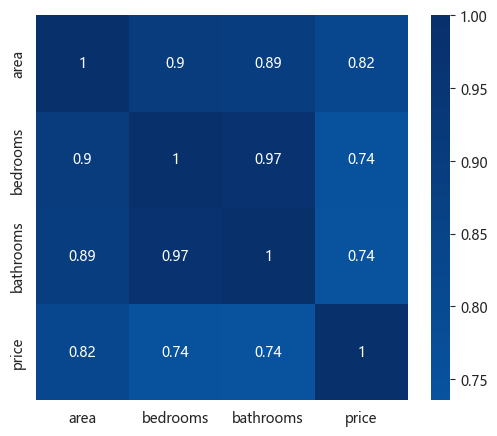

In [3]:
# 丢弃无用的house_id列
data = df.drop(columns=['house_id','neighborhood','style'])
plt.figure(figsize=(6,5))
sns.heatmap(data=data.corr(),
            xticklabels=data.corr().columns,
            yticklabels=data.corr().columns,
            cmap='Blues',
            annot=True,
            center=0)
plt.show()

**关键发现：**
- 自变量（area、bedrooms、bathrooms）与因变量price都具有较强相关性
- 但自变量之间相关性也较强（area与bedrooms相关系数0.9，bedrooms与bathrooms相关系数0.97），这提示存在多重共线性问题

In [4]:
from statsmodels.formula.api import ols
# ols能够实现最小二乘法的多元线性回归
#~的左边是因变量，右边是自变量，自变量不止一个时，用‘+’将其连接
lm = ols('price~area+bedrooms+bathrooms', data = df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     4222.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:13:24   Log-Likelihood:                -84476.
No. Observations:                6025   AIC:                         1.690e+05
Df Residuals:                    6021   BIC:                         1.690e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.007e+04   1.04e+04      0.971      0.332   -1.03e+04    3.04e+04
area         345.9134      7.229     47.848      0.000     331.741     360.086
bedrooms   -2932.4997   1.03e+04     -0.286      0.775    -2.3e+04    1.72e+04
bathrooms   7356.6733   1.43e+04      0.515      0.606   -2.06e+04    3.53e+04
==============================================================================
Omnibus:                      368.142   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              350.095
Skew:                           0.535   Prob(JB):                     9.50e-77
Kurtosis:                       2.502   Cond. No.                     1.16e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**模型结果摘要：**
- R-squared: 0.678（模型解释力）
- Adj. R-squared: 0.678（调整R方）
- F-statistic: 4230.（F统计量）
- Prob (F-statistic): 0.00（模型显著性）

### 1. 模型整体表现
- **R-squared (0.678)**：模型解释了约 67.8% 的房价（price）变异，说明拟合效果尚可。
- **F-statistic (4222.0)**，**Prob(F-statistic) (0.00)**：整体模型显著，说明至少有一个自变量对房价有显著影响。
- **样本量 (6025)**：样本量充足，统计推断的可靠性较高。

---

### 2. 各变量系数解读
| 变量        | 系数 (coef)   | P值 (P>\|t\|) | 解读                                                                 |
|-------------|---------------|--------------|--------------------------------------------------------------------|
| Intercept   | 1007e+04      | 0.332        | 截距项不显著，在所有自变量为0时的理论房价，无实际经济意义。           |
| area        | 345.9134      | 0.000        | **显著**。面积每增加1单位，房价平均增加约345.91，符合预期。           |
| bedrooms    | -2932.9997    | 0.775        | **不显著**。卧室数量的系数为负且不显著，可能存在多重共线性或模型设定问题。 |
| bathrooms   | 7356.6733     | 0.606        | **不显著**。卫生间数量系数为正但不显著，同样可能受多重共线性影响。     |

---

### 3. 诊断与警告
- **Condition No. (1.16e+04)**：条件数非常大，远大于1000，提示存在**严重的多重共线性**。这很可能是卧室数（bedrooms）和卫生间数（bathrooms）与房屋面积（area）高度相关导致的。
- **Omnibus、JB 检验**：P值接近0，说明残差不服从正态分布，可能需要对数据进行变换或考虑其他模型。
- **Durbin-Watson (2.007)**：接近2，说明残差基本无自相关。

---

### 4. 结论与建议
1.  **核心发现**：房屋面积（area）是影响房价的唯一显著正向因素。
2.  **主要问题**：多重共线性导致卧室数和卫生间数的系数不显著，甚至符号反常。
3.  **改进方向**：
    -   检查变量间的相关性，考虑移除高度相关的变量或使用岭回归（Ridge Regression）等方法。
    -   对数据进行标准化或中心化处理，缓解多重共线性。
    -   检查残差分布，考虑对因变量（如房价）进行对数变换。

---

# 3.模型分析与评估

## 3.1 模型的评估指标（R方和调整R方）

## R方（决定系数）

$$
R^2 = \frac{\text{SSR}}{\text{SST}} = \frac{\sum_{i=1}^n (\hat{y}_i - \bar{y})^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
$$

- **含义**：描述因变量中有多少方差可以由自变量来解释
- **判断标准**：$R^2$ 越接近1，模型拟合效果越好；一般 $R^2 > 0.8$ 说明拟合效果优异
- **本例问题**：$R^2 = 0.678$，还有很大提升空间

---

## 调整R方（Adjusted R-squared）

$$
R_{\text{adj}}^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}
$$

- **n**：样本容量
- **p**：自变量个数

作用：对添加的非显著变量进行惩罚，避免过拟合

## 3.2回归系数的显著性检验

获取回归系数：

In [5]:
# params方法保存回归系数和截距
lm = ols('price~area+bedrooms+bathrooms', data = df).fit()
lm.params

Intercept    10065.033227
area           345.913386
bedrooms     -2932.499740
bathrooms     7356.673320
dtype: float64

回归方程：price = 10065 + area×345 - bedrooms×2932 + bathrooms×7356 + ε

假设检验：

- 零假设：所有自变量的回归系数都等于零（自变量对因变量无显著影响）
- 备择假设：至少有一个自变量的回归系数不等于零

检验统计量：

F=MSR/MSE

- MSR：回归平方和的均方
- MSE：误差平方和的均方
- 判断：p值 < 0.05 表示回归系数显著

## 3.3 虚拟变量的设置

背景：

- 分类变量（neighborhood、style）无法直接放入线性回归模型，需要转换为虚拟变量
- 本例使用One-Hot编码

原理：

- 将n类分类变量拆分为n个二元虚拟变量（0或1）
- 关键：放入模型时需要舍弃一个（drop_first=True），因为n-1个变量已足够获取所有信息（避免多重共线性）

生成虚拟变量：

In [8]:
dummies = pd.get_dummies(data = df[['neighborhood','style']],
                         prefix = '',
                         drop_first = True)
# prefix表示可以指定前缀
# drop_first 自动舍弃生成的虚拟变量中的第一个，因为只要其中两个，剩下的一个便可反推
dummies.sample()

,_B,_C,_ranch,_victorian
270,False,True,False,True


In [9]:
# 将虚拟变量与原数据集拼接
results = pd.concat(objs=[df,dummies],axis='columns')
# 按照列来合并，并丢弃原始的neighborhood和style列
results.drop(columns=['house_id','neighborhood','style'],inplace=True)
results.sample(2)

,area,bedrooms,bathrooms,price,_B,_C,_ranch,_victorian
5320,1374,3,2,689989,True,False,False,True
3866,1089,2,1,282391,False,False,False,False


In [10]:
# 再次建模
Im = ols('price~area+bedrooms+bathrooms+_B+_C+_ranch+_victorian', data = results).fit()
Im.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     9804.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        22:01:16   Log-Likelihood:                -80302.
No. Observations:                6025   AIC:                         1.606e+05
Df Residuals:                    6017   BIC:                         1.607e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           -2.03e+05   6213.818    -32.665      0.000   -2.15e+05   -1.91e+05
_B[T.True]          5.247e+05   4573.826    114.729      0.000    5.16e+05    5.34e+05
_C[T.True]            -8.1928   4962.920     -0.002      0.999   -9737.294    9720.909
_ranch[T.True]     -7661.6977   6677.620     -1.147      0.251   -2.08e+04    5428.831
_victorian[T.True] -1.376e+04   8232.707     -1.672      0.095   -2.99e+04    2376.233
area                 343.7648      3.788     90.757      0.000     336.339     351.190
bedrooms            7996.7364   5310.427      1.506      0.132   -2413.604    1.84e+04
bathrooms          -4256.9855   7177.845     -0.593      0.553   -1.83e+04    9814.163
==============================================================================
Omnibus:                      126.337   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              154.665
Skew:                           0.288   Prob(JB):                     2.60e-34
Kurtosis:                       3.533   Cond. No.                     1.30e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.3e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 1. 模型性能：
*   **R-squared 从 0.678 提升到 0.919**：
    这意味着模型对房价的解释能力从原来的 67.8% 跃升至 **91.9%**。
    *   **含义**：**房屋的地理位置（neighborhood）和建筑风格（style）是决定房价的关键因素**。仅仅加入这两个维度的信息，就弥补了近 25% 的预测误差。
*   **F-statistic 显著增大**：
    统计量从 4222 变为 9804，且 P值仍为 0.000，证明加入这些虚拟变量后，**整个模型的解释力极其显著**。

### 2. 变量系数的含义解读
加入分类变量后，连续变量（area/bedrooms/bathrooms）的显著性也发生了变化，我们需要分两类看：

#### A. 分类变量（虚拟变量）的影响
这些变量反映了“基准组”（被`drop_first=True`删掉的那个类别）与当前类别的房价差异：
1. **`_B[T.True]` (系数 52.47万, P=0.000)**：
    *   **含义**：位于社区 B 的房屋，相比基准社区，房价平均高出 **52.47万**，且该结果极显著。这是影响房价的第一大因素。
2. **`_victorian[T.True]` (系数 -1.38万, P=0.095)**：
    *   **含义**：维多利亚风格的房屋，相比基准风格，房价平均低 **1.38万**，在 10% 的置信水平下边缘显著。
3. **`_C[T.True]` 和 `_ranch[T.True]` (P值 > 0.05)**：
    *   **含义**：这两个类别与基准组之间的房价差异在统计上不显著，即模型认为它们和基准组没区别。

#### B. 连续变量的变化
对比上一次结果，连续变量的表现有了有趣的反转：
1. **`area` (面积)**：依然显著（P=0.000），系数稳定在 343 左右。
    *   **含义**：在**控制了社区和风格**之后，面积每增加1单位，房价仍稳定上涨约 343。这证明面积的影响是独立且可靠的。
2. **`bedrooms` (卧室)**：上一次不显著且为负，这次变为正（7996）且边缘显著（P=0.132）。
    *   **含义**：这是一个关键修正！之前的负系数是因为**多重共线性**和**未控制社区因素**导致的。现在引入了社区和风格，卧室数的正向影响开始显现（虽然还没完全显著）。
3. **`bathrooms` (浴室)**：依然不显著（P=0.553）。
    *   **含义**：在控制了面积和社区后，浴室数量对房价的额外贡献很小，可能浴室数已经和面积高度相关了。

### 3. 依然存在的隐患（重要）
虽然效果很好，但表格底部的警告依然存在：
*   **Condition No. (1.30e+04)**：条件数依然很大，说明**多重共线性问题没有解决**，反而可能因为加入了虚拟变量而加剧。
*   **后果**：多重共线性会导致系数的标准误（std err）变大，使得原本可能显著的变量（如 bedrooms）变得不显著。


## 3.4 多重共线性的诊断

定义：

多重共线性是指数据集中存在两个或多个自变量之间高度相关的情况，会导致：
- 回归系数估计不稳定
- 结果非常敏感、不可靠甚至完全相反
- 模型预测和解释能力大大降低

方差膨胀因子：

# 方差膨胀因子（VIF）：

$$
\text{VIF}_i = \frac{1}{1 - R_i^2}
$$

- **判断标准**：$\text{VIF} > 10$ 说明存在严重的多重共线性
- $R_i^2$：将自变量 $i$ 作为因变量，与其他自变量回归时的 $R^2$

发现问题：
- 从回归方程看：bathrooms系数为-4256（浴室越多房价越低？这不符合常理！）
- 通过箱型图和热力图（图2-12）发现：area、bedrooms、bathrooms之间存在强相关性（bedrooms与bathrooms相关系数0.97）

自定义VIF检测函数：

In [18]:
def vif(df,col_i):
    '''
    df：整份数据
    col_i:被检测的自变量名，返回vif
    '''
    cols = list(df.columns)
    cols.remove(col_i)
    # 将被检测的自变量移除，当成因变量，与剩下的自变量进行回归
    cols_noti = cols
    formula = col_i+'~' + '+'.join(cols_noti)
    # 构建多元线性回归ols函数中的字符串公式
    r2 = ols(formula, data = df).fit().rsquared
    # 自变量之间的回归，并调取模型的R方
    return 1./(1.-r2)

检测所有的连续变量：

In [19]:
test_data = results[['area','bedrooms','bathrooms','_B','_C','_ranch','_victorian']]
test_data = test_data.astype('float')
# 转换布尔列为整数
for i in test_data.columns:
    print(i,'\t',vif(df = test_data,col_i = i))

area 	 5.977642975134142
bedrooms 	 22.300457194928203
bathrooms 	 19.17238588773045
_B 	 1.3704077751640023
_C 	 1.370432278895806
_ranch 	 2.546218338287573
_victorian 	 4.615346369263233


检测结果：

| 变量                             | VIF值      | 说明              |
| ------------------------------ | --------- | --------------- |
| area                           | 5.98      | 正常              |
| **bedrooms**                   | **22.31** | **>10，严重多重共线性** |
| **bathrooms**                  | **19.19** | **>10，严重多重共线性** |
| \_B, \_C, \_ranch, \_victorian | 1.37-4.61 | 正常              |

处理方法：
- 方法1：删除VIF值较大的变量（删除bedrooms）
- 方法2：构造综合变量total_rooms = bedrooms + bathrooms

使用方法一重新建模：

In [22]:
data_copy = results.copy()
data_copy.drop(columns = ['bedrooms'],inplace=True)
Im = ols('price~area+bathrooms+_B+_C+_ranch+_victorian', data = data_copy).fit()
Im.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                 1.144e+04
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:01:04   Log-Likelihood:                -80303.
No. Observations:                6025   AIC:                         1.606e+05
Df Residuals:                    6018   BIC:                         1.607e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -1.984e+05   5431.187    -36.535      0.000   -2.09e+05   -1.88e+05
_B[T.True]          5.247e+05   4574.044    114.707      0.000    5.16e+05    5.34e+05
_C[T.True]            -0.7069   4963.440     -0.000      1.000   -9730.828    9729.414
_ranch[T.True]     -5468.1137   6517.482     -0.839      0.402   -1.82e+04    7308.486
_victorian[T.True] -1.064e+04   7968.152     -1.335      0.182   -2.63e+04    4979.998
area                 345.7241      3.558     97.178      0.000     338.750     352.698
bathrooms           4459.5398   4244.932      1.051      0.294   -3862.047    1.28e+04
==============================================================================
Omnibus:                      120.685   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              147.552
Skew:                           0.280   Prob(JB):                     9.11e-33
Kurtosis:                       3.524   Cond. No.                     1.30e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.3e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

---

### 1. 模型整体表现
- **R-squared / Adj. R-squared (0.919)**：模型解释力和之前完全一致，说明删除 `bedrooms` 后，模型对房价变异的解释能力没有损失。
- **F-statistic (11440)**：比之前的 9804 更大，且 P值为 0.000，表明在移除一个变量后，模型的整体显著性反而增强了。
- **Cond. No. (1.3e+04)**：条件数依然很大，说明虽然移除了 `bedrooms`，但多重共线性问题仍然存在，主要是 `bathrooms` 和其他变量（尤其是 `area`）之间的相关性导致的。

---

### 2. 变量系数与显著性解读

| 变量 | 系数 (coef) | P值 (P>\|t\|) | 解读 |
| :--- | :--- |:-------------| :--- |
| **Intercept** | -198405 | 0.000        | 截距项显著为负，在所有自变量为0时的理论房价，无实际经济意义。 |
| **_B[T.True]** | 524700 | 0.000        | **极显著**。位于社区 B 的房屋，相比基准社区，房价平均高出约 **52.47万**，这是影响房价的最核心因素。 |
| **_C[T.True]** | -0.71 | 1.000        | **完全不显著**。社区 C 与基准社区的房价没有差异。 |
| **_ranch[T.True]** | -5468 | 0.402        | **不显著**。牧场风格房屋与基准风格的房价差异不明显。 |
| **_victorian[T.True]** | -10640 | 0.182        | **不显著**。维多利亚风格房屋比基准风格便宜约 1.06万，但统计上不显著。 |
| **area** | 345.72 | 0.000        | **极显著**。在控制其他因素后，房屋面积每增加1单位，房价平均增加约 **345.72元**。 |
| **bathrooms** | 4459.54 | 0.294        | **不显著**。浴室数量的正向影响在统计上不显著，说明它和面积高度相关，其信息已被面积变量“吸收”。 |

---

### 3. 核心结论与下一步建议

1.  **核心发现**：
    - **社区位置（_B）** 是影响房价的绝对主导因素，远超面积的影响。
    - **房屋面积（area）** 是唯一稳定且显著的连续型变量。
    - 删除 `bedrooms` 后，`bathrooms` 依然不显著，说明多重共线性问题并未彻底解决。

2.  **多重共线性问题**：
    - 条件数（Cond. No.）依然高达 1.3e+04，表明 `bathrooms` 和 `area` 之间仍然存在严重的共线性。
    - 这也解释了为什么 `bathrooms` 的系数不显著——它的效应已经被 `area` 所覆盖。

3.  **下一步建议**：
    - 当前模型（R²=0.919）已经非常强大，可以直接使用。
---

使用方法2进行建模：

In [24]:
# 1. 复制已处理好虚拟变量的数据集（避免破坏原始数据）
data_new = results.copy()

# 2. 构造综合变量 total_rooms
data_new['total_rooms'] = data_new['bedrooms'] + data_new['bathrooms']

# 3. 删除原来的 bedrooms 和 bathrooms 列（避免多重共线性）
data_new = data_new.drop(columns=['bedrooms', 'bathrooms'])

# 4. 重新构建回归模型
lm_new = ols('price ~ area + total_rooms + _B + _C + _ranch + _victorian',
             data=data_new).fit()

lm_new.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                 1.144e+04
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:04:41   Log-Likelihood:                -80302.
No. Observations:                6025   AIC:                         1.606e+05
Df Residuals:                    6018   BIC:                         1.607e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -2.002e+05   5581.452    -35.861      0.000   -2.11e+05   -1.89e+05
_B[T.True]          5.247e+05   4573.424    114.725      0.000    5.16e+05    5.34e+05
_C[T.True]           -29.7945   4962.902     -0.006      0.995   -9758.860    9699.271
_ranch[T.True]     -7384.3494   6672.237     -1.107      0.268   -2.05e+04    5695.625
_victorian[T.True] -1.324e+04   8217.128     -1.611      0.107   -2.93e+04    2868.457
area                 343.9894      3.782     90.966      0.000     336.576     351.402
total_rooms         2881.7974   1896.877      1.519      0.129    -836.762    6600.357
==============================================================================
Omnibus:                      124.546   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.537
Skew:                           0.285   Prob(JB):                     7.53e-34
Kurtosis:                       3.531   Cond. No.                     1.29e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.29e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

---

### 1. 模型整体表现
- **R-squared / Adj. R-squared (0.919)**：与方案一完全一致，说明模型对房价的解释力没有变化，依然能解释约91.9%的房价变异。
- **F-statistic (11440)**：与方案一相同，模型整体显著性极强，所有变量联合起来对房价有显著影响。
- **Cond. No. (1.29e+04)**：条件数依然很大，说明多重共线性问题只是得到缓解，并未彻底解决，这主要是因为 `area` 与其他变量（尤其是虚拟变量）之间的强相关性仍然存在。

---

### 2. 变量系数与显著性解读

| 变量 | 系数 (coef) | P值 (P>\|t\|) | 解读 |
| :--- | :--- |:-------------| :--- |
| **Intercept** | -200200 | 0.000        | 截距项显著为负，无实际经济意义，仅用于模型拟合。 |
| **_B[T.True]** | 524700 | 0.000        | **极显著**。位于社区 B 的房屋，相比基准社区，房价平均高出约 **52.47万**，这是影响房价的最核心因素。 |
| **_C[T.True]** | -29.80 | 0.995        | **完全不显著**。社区 C 与基准社区的房价几乎没有差异。 |
| **_ranch[T.True]** | -7384.35 | 0.268        | **不显著**。牧场风格房屋与基准风格的房价差异不明显。 |
| **_victorian[T.True]** | -13240 | 0.107        | **接近显著**。维多利亚风格房屋比基准风格便宜约 1.32万，在10%的显著性水平下有一定解释力。 |
| **area** | 343.99 | 0.000        | **极显著**。在控制其他因素后，房屋面积每增加1单位，房价平均增加约 **344元**。 |
| **total_rooms** | 2881.80 | 0.129        | **不显著**。房间总数（卧室+浴室）每增加1，房价平均增加约2882元，但在统计上不显著，说明其效应被面积等其他变量覆盖。 |

---

### 3. 方案二与方案一的对比
- **模型拟合度**：两者的 R²、F-statistic 完全相同，说明在预测能力上没有区别。
- **变量显著性**：
  - 社区 B 和面积依然是最显著的变量。
  - 方案一中的 `bathrooms` 和方案二中的 `total_rooms` 都不显著，这说明房间数量的信息已经被面积变量充分吸收。
- **多重共线性**：两者的条件数都很大，说明问题根源在于 `area` 与虚拟变量之间的相关性，而非 `bedrooms` 和 `bathrooms` 之间。

---

### 4. 核心结论与下一步建议
1.  **核心发现**：
    - **社区位置（_B）** 和 **房屋面积（area）** 是影响房价的两个最稳定、最显著的因素。
    - 无论是删除 `bedrooms`，还是将其与 `bathrooms` 合并为 `total_rooms`，都无法让房间数量变量变得显著，这说明在当前数据中，面积已经很好地代表了房屋的“大小”和“价值”。
2.  **多重共线性问题**：
    - 条件数依然很高，说明模型仍存在数值稳定性问题。
3.  **模型选择建议**：
      - 当前模型（R²=0.919）已经非常优秀，可以直接使用。
---

## 3.5 残差分析

| 类型       | 图形特征                | 含义               |
| -------- | ------------------- | ---------------- |
| (a) 正常   | 残差随机分布，上下界对称        | 方差基本为齐性，模型正常     |
| (b) 线性   | 残差和预测值呈线性关系         | 自变量和因变量间可能不是线性关系 |
| (c) 异方差性 | 上下基本对称，但幅度随预测值增大而增加 | 残差方差不齐，需进一步修正    |
| (d) 周期性  | 残差随预测值增大呈现周期性变化     | 可能是周期变化关系        |

绘制残差图：

<Axes: xlabel='price_predict', ylabel='residual'>

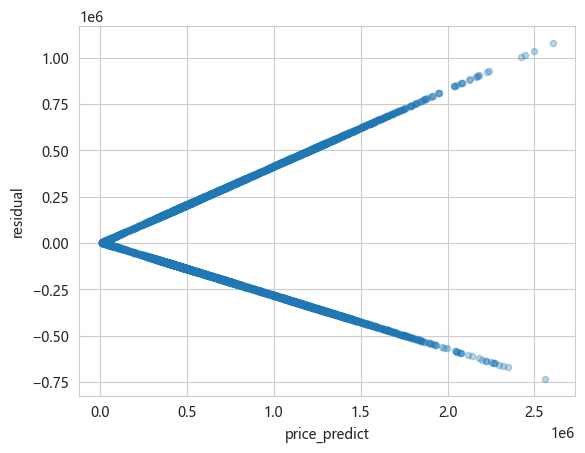

In [25]:
lm = ols('price~area',data = df).fit()
df['price_predict'] = lm.predict() # 使用建好的模型进行预测
df['residual'] = df['price']-df['price_predict']
df.plot(x = 'price_predict',y = 'residual',kind = 'scatter',alpha = 0.3)
# alpha 表示点的透明度

发现问题：
- 残差呈现两条直线（因房价标准差和分布差异大）
- 存在异方差问题（随着预测值增大，残差幅度逐渐增大）

处理方法：
- 变量转换：对自变量或因变量进行数学变换（取对数、平方根等）
- 权值回归：使用加权最小二乘法
- 广义最小二乘回归：估计方差函数并纳入模型

对数变换：

<Axes: xlabel='price', ylabel='Count'>

Text(0.5, 1.0, 'Price')

<Axes: xlabel='price_log', ylabel='Count'>

Text(0.5, 1.0, 'Log(Price)')

<Axes: xlabel='area', ylabel='Count'>

Text(0.5, 1.0, 'Area')

<Axes: xlabel='area_log', ylabel='Count'>

Text(0.5, 1.0, 'Log(Area)')

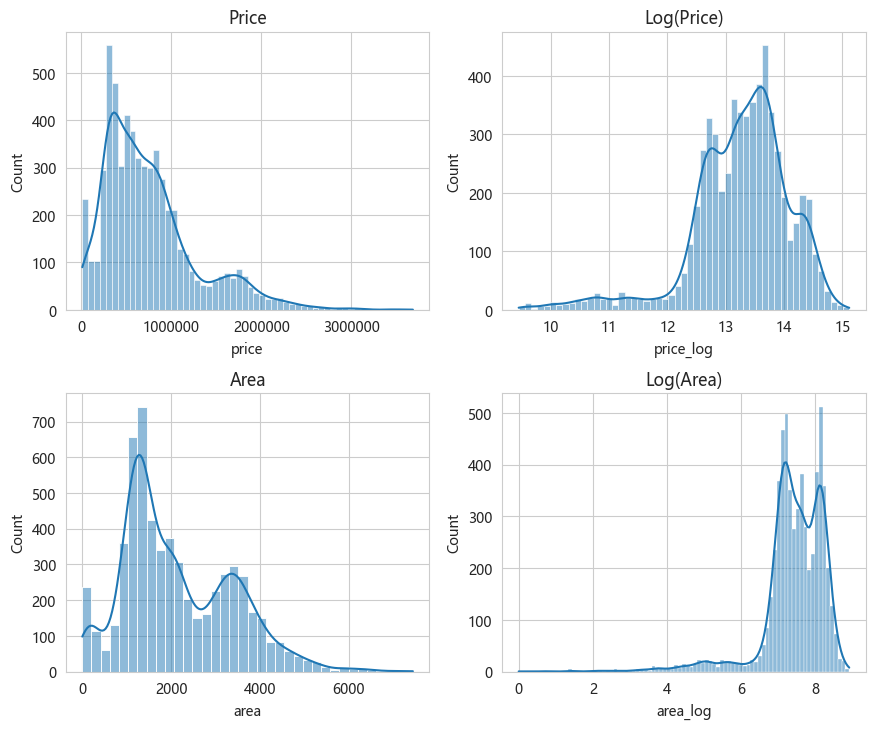

In [26]:
# 对自变量和因变量均进行取对数处理
df['price_log'] = np.log(df['price'])
df['area_log'] = np.log(df['area'])
# 绘制子图
fig,axs = plt.subplots(ncols=2,nrows=2,figsize=(10,8))
sns.histplot(df['price'],kde = True,ax=axs[0][0])
axs[0][0].set_title('Price')
sns.histplot(df['price_log'],kde = True,ax=axs[0][1])
axs[0][1].set_title('Log(Price)')
sns.histplot(df['area'],kde = True,ax=axs[1][0])
axs[1][0].set_title('Area')
sns.histplot(df['area_log'],kde = True,ax=axs[1][1])
axs[1][1].set_title('Log(Area)')
plt.subplots_adjust(left = 0.1,right = 0.9,bottom = 0.1,top = 0.9,wspace = 0.2,hspace = 0.3)
# 关闭科学计数法
axs[0][0].ticklabel_format(style='plain', axis='x')
plt.show()

数据的离散程度大大减小了

未对自变量和因变量取对数时，模型的R方：0.6777538929154125
对自变量和因变量取对数后，模型的R方：0.836541682336059


<Axes: xlabel='price_predict_log', ylabel='residual'>

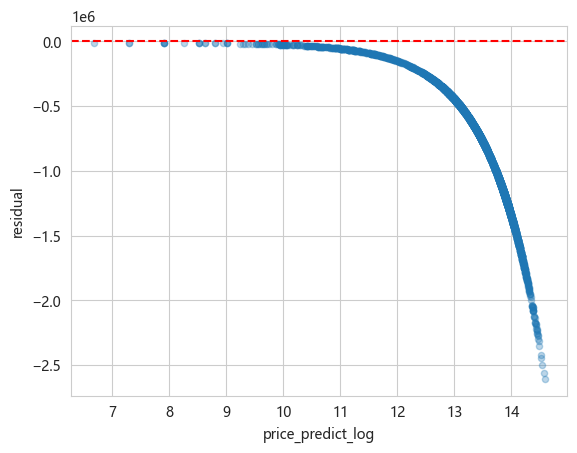

In [27]:
# 对比模型精度
lm = ols('price~area',data = df).fit()
print(f'未对自变量和因变量取对数时，模型的R方：{lm.rsquared}')
lm = ols('price_log~area_log',data = df).fit()
print(f'对自变量和因变量取对数后，模型的R方：{lm.rsquared}')

df['price_predict_log'] = lm.predict()
df['residual'] = df['price_log']-df['price_predict']
df.plot(x = 'price_predict_log',y = 'residual',kind = 'scatter',alpha = 0.3)
plt.axhline(y= 0,color = 'r',linestyle = '--')

结果对比：
- 未取对数时R方：0.678
- 取对数后R方：0.837（显著提升）
- 残差分布明显改善，但仍存在少量异常值